# From letters to networks
### A correspondence-network lab on American diplomacy in Europe, 1777–1784

**Course:** Natural Language Processing and Large Language Models for Historical Research · **Level:** upper-year undergraduate / MA · **Time:** 90 minutes (core stages 1–7), with optional stages 8–9

This lab is about **method**. You will build a correspondence network from the metadata of four documentary editions (the papers of Benjamin Franklin, John Adams, Thomas Jefferson and John Jay, as published on *Founders Online*), and you will make, test and defend each decision that turns documents into nodes and edges.

**Research question.** *Who connected the American diplomatic effort in Europe between 1777 and 1784, and how much of any answer comes from the archive rather than from the past?*

**What you hand in:** this notebook with answers Q1–Q7 completed (Q8–Q9 if you do the optional stages), and the 300-word memo in Stage 10.

| Stage | Task | Minutes |
|---|---|---|
| 1 | Documents become records | 10 |
| 2 | Names become entities | 15 |
| 3 | Records become edges | 10 |
| 4 | One edition, one network | 10 |
| 5 | Remove the editor | 10 |
| 6 | Merge four editions | 15 |
| 7 | Communities: people or archives? | 15 |
| 8 | *(optional)* The network over time | – |
| 9 | *(optional)* How fragile are the rankings? | – |
| 10 | Memo | 5 in class, finish at home |

Run each code cell in order (Shift+Enter). You do not need to write code, but you may change any argument marked **`# try:`**.

In [1]:
import pandas as pd, networkx as nx, matplotlib.pyplot as plt
import netlab as nl
pd.set_option("display.max_colwidth", 70); pd.set_option("display.width", 160)
records = nl.load_records("data/records.csv")
print(f"{len(records):,} documents")
records.groupby("edition").size().rename("documents").to_frame()

20,747 documents


,documents
edition,
Adams,6257
Franklin,9841
Jay,849
Jefferson,3800


## Stage 1 · Documents become records

Every row in `records.csv` is one **document** in a documentary edition: its title as the editors wrote it, its date, and the editors' list of authors and recipients. A document is not always a letter, and a record is not always one letter.

**Do:** run the cell, then open three of the permalinks in your browser and compare the page with the row.

In [2]:
sample = records.sample(8, random_state=4)[["edition", "date", "title", "authors", "recipients", "permalink"]]
sample

,edition,date,title,authors,recipients,permalink
13924,Franklin,1781-11-22,"John Adams to Benjamin Franklin, 22 November 1781","[Adams, John]","[Franklin, Benjamin]",https://founders.archives.gov/documents/Franklin/01-36-02-0069
6689,Franklin,1779-10-14,"Marquis de Lafayette to Benjamin Franklin, 14 October 1779","[Lafayette, Marie-Joseph-Paul-Yves-Roch-Gilbert du Motier, marquis...","[Franklin, Benjamin]",https://founders.archives.gov/documents/Franklin/01-30-02-0413
15698,Franklin,1782-07-25,"——— Faesch to Benjamin Franklin, 25 July 1782","[Faesch, ——]","[Franklin, Benjamin]",https://founders.archives.gov/documents/Franklin/01-37-02-0440
9932,Franklin,1780-10-15,"Vergennes to Benjamin Franklin, 15 October 1780","[Vergennes, Charles Gravier, comte de]","[Franklin, Benjamin]",https://founders.archives.gov/documents/Franklin/01-33-02-0354
18353,Franklin,1783-09-09,"Sarah Bache to Benjamin Franklin, 9 September 1783","[Bache, Sarah Franklin]","[Franklin, Benjamin]",https://founders.archives.gov/documents/Franklin/01-40-02-0376
8649,Adams,1780-06-05,"Arthur Lee to John Adams, 5 June 1780","[Lee, Arthur]","[Adams, John]",https://founders.archives.gov/documents/Adams/06-09-02-0241
15255,Adams,1782-05-16,"Edmund Jenings to John Adams, 16 May 1782","[Jenings, Edmund]","[Adams, John]",https://founders.archives.gov/documents/Adams/06-13-02-0023
13210,Adams,1781-07-03,Tuesday July the 3d 1781.,"[Adams, John Quincy]",[],https://founders.archives.gov/documents/Adams/03-01-02-0003-0002-0003


The editions contain more than letters. The next cell counts some of the cases that need a decision before anything can be called a network.

In [3]:
def kind(r):
    if not r.recipients: return "no recipient (diary, account, memorandum, draft...)"
    if "Two Letters" in r.title or "Three Letters" in r.title: return "one record = several letters"
    if len(r.authors) > 1 or len(r.recipients) > 1: return "several senders or recipients"
    return "one sender, one recipient"
records["record_kind"] = records.apply(kind, axis=1)
pd.crosstab(records.record_kind, records.edition, margins=True)

edition,Adams,Franklin,Jay,Jefferson,All
record_kind,,,,,
"no recipient (diary, account, memorandum, draft...)",1423,306,53,392,2174
one record = several letters,0,161,0,0,161
"one sender, one recipient",3856,7989,770,3244,15859
several senders or recipients,978,1385,26,164,2553
All,6257,9841,849,3800,20747


**Question 1.** Choose one row from the 'no recipient' group and one from the 'several senders or recipients' group (filter with `records[records.record_kind == "..."]`). For each, say what the document is and whether it should become part of a *correspondence* network.

In [4]:
records[records.record_kind == "several senders or recipients"].sample(5, random_state=1)[["title", "authors", "recipients"]]  # try: another random_state

,title,authors,recipients
3211,"Thomas Simpson to the Commissioners, 3 July 1778","[Simpson, Thomas]","[First Joint Commission at Paris, Adams, John]"
3754,"John Bondfield to the American Commissioners, 8 September 1778: ré...","[Bondfield, John]","[American Commissioners, Franklin, Benjamin, Lee, Arthur, Adams, J..."
3804,"Dumas to the American Commissioners, 13[â€”18] September 1778: résumé","[Dumas, Charles-Guillaume-Frédéric]","[American Commissioners, Franklin, Benjamin, Lee, Arthur, Adams, J..."
4597,"John Bondfield to the Commissioners, 1 January 1779","[Bondfield, John]","[Franklin, Benjamin, Lee, Arthur, Adams, John, First Joint Commiss..."
3839,"The American Commissioners to Sartine, 17 September 1778: résumé","[American Commissioners, Franklin, Benjamin, Lee, Arthur, Adams, J...","[Sartine, Antoine-Raymond-Gualbert-Gabriel de]"


> **Your answer (Q1):**
>
> _Write here._

## Stage 2 · Names become entities

A node is only as good as the decision that two strings name the same thing. Three problems appear at once:

1. **Different kinds of correspondent.** Persons, firms, and groups such as *American Commissioners* or *President of Congress*.
2. **The same person, different strings.** Each edition has its own editorial conventions.
3. **Different people, similar strings.** John Adams and John Quincy Adams, William Franklin and William Temple Franklin.

In [5]:
from collections import Counter
names = Counter(n for L in list(records.authors) + list(records.recipients) for n in L)
types = pd.Series({n: nl.entity_type(n) for n in names})
print(types.value_counts().to_string())
pd.DataFrame({"mentions": pd.Series(names)}).assign(type=types).query("type == 'group'").sort_values("mentions", ascending=False).head(10)

person       3106
firm          153
group         122
pseudonym       9
unknown         2


,mentions,type
American Commissioners,1151,group
First Joint Commission at Paris,417,group
President of Congress,302,group
Committee of the Virginia Assembly,128,group
American Peace Commissioners,112,group
Board of Trade,97,group
Board of War,87,group
Virginia Assembly,82,group
Virginia Delegates,62,group
Committee for Foreign Affairs,43,group


`variant_candidates` lists pairs of person-names that share a surname and part of a forename. **String similarity is not evidence of identity**: read the table as a list of questions, not answers.

In [6]:
cands = nl.variant_candidates(records, min_letters=3)
cands.head(25)

,name_a,letters_a,editions_a,name_b,letters_b,editions_b,string_similarity
0,"Gellée, Nicolas-Maurice",3,Franklin,"Gellée, Nicolas Maurice",3,Adams,1.00
1,"La Vauguyon, Paul François de Quélen de Stuer de Causade, Duc de",27,Adams,"La Vauguyon, Paul-François de Quélen de Stuer de Caussade, duc de",3,Franklin,0.99
2,"Aranda, Pedro Pablo Abarca de Bolea, Conde de",8,Franklin,"Aranda, Pedro Pablo Abarca de Bolea, count de",10,Adams+Jay+Jefferson,0.96
3,"Williams, Jonathan Jr.",437,Franklin,"Williams, Jonathan Sr.",27,Franklin,0.95
4,"Vernon, William, Sr.",15,Adams+Franklin,"Vernon, William, Jr.",6,Adams,0.95
5,"Smith, Isaac, Sr.",30,Adams,"Smith, Isaac, Jr.",3,Adams,0.94
6,"Schweighauser, Jean-Daniel",67,Franklin,"Schweighauser, John Daniel",23,Adams,0.92
7,"Capellen tot den Pol, Joan Derk van der",3,Franklin,"Capellen tot den Pol, Joan Derk, Baron van der",27,Adams,0.92
8,"Williams, Jonathan Sr.",27,Franklin,"Williams, Jonathan",28,Adams,0.90
9,"Williams, Jonathan Jr.",437,Franklin,"Williams, Jonathan",28,Adams,0.90


The file `data/name_authority.csv` records decisions made for this lab: `merge`, `probable` (plausible but unverified), and `keep separate`, each with a reason.

In [7]:
authority = pd.read_csv("data/name_authority.csv")
print(authority.decision.value_counts().to_string())
authority

decision
merge            19
keep separate    11
probable          4


,variant,canonical,decision,basis
0,"Dumas, Charles William Frederick","Dumas, Charles-Guillaume-Frédéric",merge,"same agent at The Hague; Adams Papers anglicise, Franklin Papers u..."
1,"Schweighauser, John Daniel","Schweighauser, Jean-Daniel",merge,American commercial agent at Nantes; anglicised vs French form
2,"Grand, Ferdinand","Grand, Rodolphe-Ferdinand",merge,Paris banker to the commissioners; short vs full form
3,"Wright, Patience Lovell","Wright, Patience",merge,wax modeller; with and without maiden name
4,"Jay, Sarah","Jay, Sarah Livingston",merge,wife of John Jay; short vs full form
5,Thomas Jefferson,"Jefferson, Thomas",merge,inverted-name form
6,"Congress, President of",President of Congress,merge,"same office, inverted form"
7,"Townshend, Thomas, first Viscount (Sydney)","Townshend, Thomas",merge,same person (Secretary of State 1782-83; created Baron Sydney 1783...
8,"Thaxter, John, Jr.","Thaxter, John",merge,John Adams's private secretary; generational suffix used in one ed...
9,"Gellée, Nicolas Maurice","Gellée, Nicolas-Maurice",merge,hyphenation


**Question 2.** Pick one pair from `cands` that is **not** in the authority file. Open a document for each name (search the name in `records`, then follow the permalink) and decide: merge, keep separate, or probable. What evidence did you use? What would it cost the analysis if you were wrong in each direction?

In [8]:
name = "Morris, Lewis"   # try: any name from the candidates table
records[records.authors.apply(lambda L: name in L) | records.recipients.apply(lambda L: name in L)][["edition", "title", "permalink"]].head(8)

,edition,title,permalink
163,Jay,"John Jay to Lewis Morris, 3 February 1777",https://founders.archives.gov/documents/Jay/01-01-02-0204
222,Jay,"Lewis Morris to John Jay, 15 February 1777",https://founders.archives.gov/documents/Jay/01-01-02-0206
337,Jay,"Lewis Morris to John Jay, 8 March 1777",https://founders.archives.gov/documents/Jay/01-01-02-0213
512,Jay,"Lewis Morris to John Jay, 14–17 April 1777",https://founders.archives.gov/documents/Jay/01-01-02-0223


> **Your answer (Q2):**
>
> _Write here._

## Stage 3 · Records become edges

An **edge** here is *one document from a sender to a recipient*. Documents without a recipient produce no edge. A document with two senders and three recipients produces six edges.

Groups raise a further choice. When the Franklin Papers list the recipients of a letter as *American Commissioners; Franklin; Deane; Lee*, is the recipient the commission, the three men, or both? `group_policy` sets the rule:

- `"individuals"`: drop the group whenever persons are also listed
- `"collective"`: drop the persons whenever the group is listed
- `"both"`: keep everything (the group becomes a node alongside its members)

In [9]:
auth = nl.load_authority("data/name_authority.csv")          # merges only; try: include_probable=True
franklin = records[records.edition == "Franklin"]
rows = []
for policy in ["individuals", "collective", "both"]:
    e = nl.to_edges(franklin, auth, group_policy=policy)
    rows.append(dict(policy=policy, edges=len(e), **nl.summary(nl.build_graph(e))))
pd.DataFrame(rows).set_index("policy")

,edges,nodes,ties,letters,density,components,largest_component,isolated_pairs
policy,,,,,,,,
individuals,12448,2329,2926,12448,0.00108,2,2327,1
collective,9873,2332,2572,9873,0.00095,2,2330,1
both,13690,2332,3154,13690,0.00116,2,2330,1


**Question 3.** Which policy fits the research question, and why? Name one historical question for which you would choose a different policy.

> **Your answer (Q3):**
>
> _Write here._

## Stage 4 · One edition, one network

Build the network from the Franklin Papers alone, using the `individuals` policy. Three ways of ranking correspondents:

- **letters**: documents sent plus documents received (weighted degree)
- **correspondents**: number of distinct people or bodies a node exchanged documents with (degree)
- **betweenness**: the share of shortest paths between other pairs of nodes that pass through a node. A node with high betweenness sits between parts of the network that are otherwise poorly connected.

{'nodes': 2329, 'ties': 2926, 'letters': 12448, 'density': 0.00108, 'components': 2, 'largest_component': 2327, 'isolated_pairs': 1}


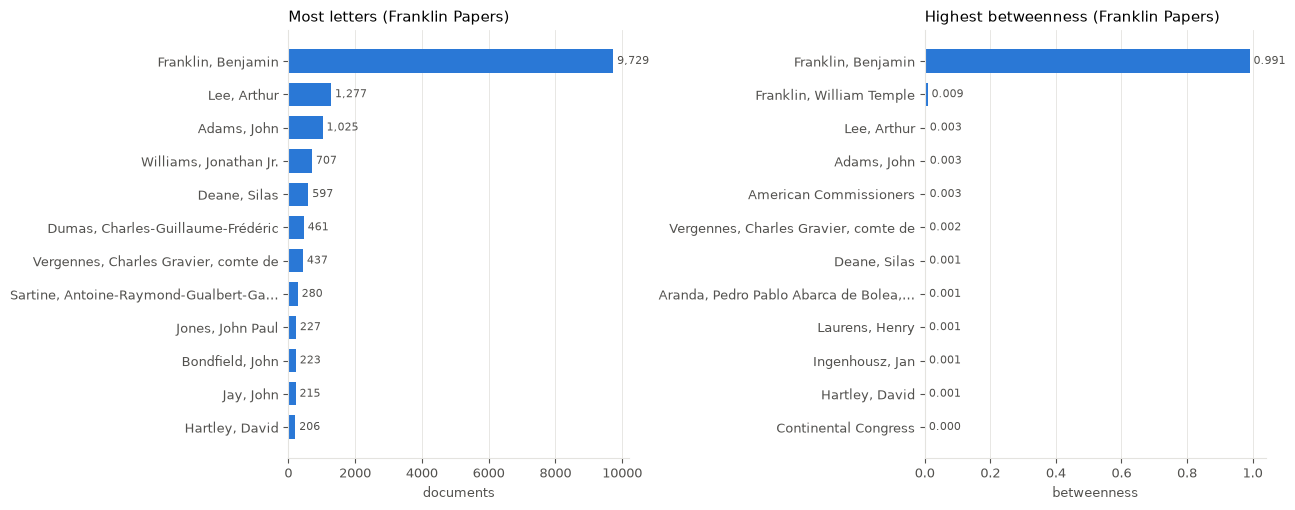

In [10]:
E_fr = nl.to_edges(franklin, auth, group_policy="individuals")
G_fr = nl.build_graph(E_fr)
M_fr = nl.metric_table(G_fr)
print(nl.summary(G_fr))
fig, axes = plt.subplots(1, 2, figsize=(13, 5.2))
nl.bar(M_fr.letters_total.head(12), "Most letters (Franklin Papers)", "documents", ax=axes[0])
nl.bar(M_fr.betweenness.sort_values(ascending=False).head(12), "Highest betweenness (Franklin Papers)", "betweenness", ax=axes[1])
plt.tight_layout()

**Question 4.** Franklin's betweenness is close to 1. Explain in two sentences why that follows from *how the edition was made*, and why it therefore tells you very little about Franklin.

> **Your answer (Q4):**
>
> _Write here._

## Stage 5 · Remove the editor

A documentary edition collects documents *to and from* its subject, plus some documents between third parties that ended up in the subject's files. Remove Franklin and see what is left.

In [11]:
G_wo = nl.without(G_fr, ["Franklin, Benjamin"])
before, after = nl.summary(G_fr), nl.summary(G_wo)
pd.DataFrame({"with Franklin": before, "without Franklin": after})

,with Franklin,without Franklin
nodes,2329.00000,296.00000
ties,2926.00000,621.00000
letters,12448.00000,2719.00000
density,0.00108,0.01422
components,2.00000,3.00000
largest_component,2327.00000,292.00000
isolated_pairs,1.00000,2.00000


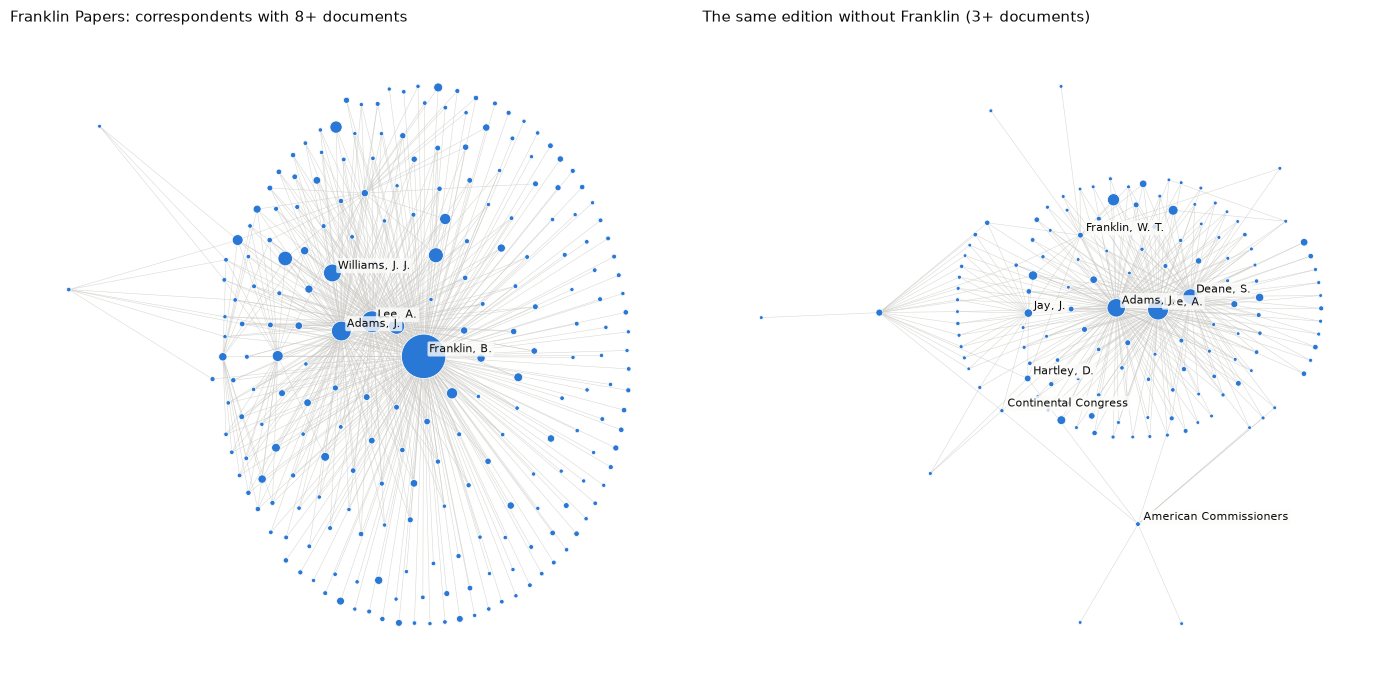

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 7))
nl.draw(G_fr, min_letters=8, title="Franklin Papers: correspondents with 8+ documents", ax=axes[0],
        labels=["Franklin, Benjamin", "Lee, Arthur", "Adams, John", "Williams, Jonathan Jr."])
M_wo = nl.metric_table(G_wo)
nl.draw(G_wo, min_letters=3, title="The same edition without Franklin (3+ documents)", ax=axes[1],
        labels=list(M_wo.sort_values("betweenness", ascending=False).index[:8]))
plt.tight_layout()

The documents that survive the removal are the ones that did **not** involve Franklin as sender or recipient. What are they?

In [13]:
third = E_fr[(E_fr.source != "Franklin, Benjamin") & (E_fr.target != "Franklin, Benjamin")]
print(f"{third.doc_id.nunique():,} of {E_fr.doc_id.nunique():,} documents with edges do not involve Franklin directly")
third.drop_duplicates("doc_id").merge(records[["doc_id", "title"]], on="doc_id").sample(8, random_state=2)[["date", "title"]]

1,279 of 9,530 documents with edges do not involve Franklin directly


,date,title
829,1778-08-27,"The American Commissioners to John Bondfield, 27 August 1778"
967,1778-11-05,"The American Commissioners to Sartine, 5 November 1778: résumé"
374,1777-12-30,"Dumas to the American Commissioners, 30 December 1777"
1144,1781-09-11,"William Robeson to William Temple Franklin, 11 September 1781"
488,1778-03-17,"Gérard to the American Commissioners, 17 March 1778"
505,1778-03-30,"James Moylan to the American Commissioners, 30 March 1778"
1125,1779-09-09,"Arthur Lee to [William Temple Franklin], 9 September 1779"
530,1778-04-13,"The American Commissioners to John Ross, 13 April 1778: résumé"


**Question 5.** Describe the network that remains without Franklin. Who holds it together, and what kinds of documents produce those ties? Is this a picture of 'Franklin's circle', of the American commission in Paris, or of something else?

> **Your answer (Q5):**
>
> _Write here._

## Stage 6 · Merge four editions

Adding the Adams, Jefferson and Jay Papers brings in other diplomats (Adams in Paris and The Hague, Jay in Madrid and Paris, Jefferson from 1784), but it also brings two new problems.

1. **Duplicates.** A letter from Adams to Franklin is printed in *both* editions. Two documents count as the same letter when they share a date, senders and recipients and come from *different* editions.
2. **Name conventions.** Duplicates can only be found once names agree, so the authority file changes the count.

In [14]:
rows = []
for label, a in [("no authority file", {}), ("merges", auth), ("merges + probable", nl.load_authority("data/name_authority.csv", include_probable=True))]:
    e = nl.to_edges(records, a)
    d, dups = nl.dedupe(e, prefer=["Franklin", "Adams", "Jefferson", "Jay"])
    rows.append(dict(authority=label, distinct_names=pd.concat([e.source, e.target]).nunique(),
                     documents=e.doc_id.nunique(), after_dedupe=d.doc_id.nunique(), duplicate_letters=dups.letter_key.nunique()))
pd.DataFrame(rows).set_index("authority")

,distinct_names,documents,after_dedupe,duplicate_letters
authority,,,,
no authority file,3318,18511,18126,354
merges,3299,18511,18063,392
merges + probable,3295,18511,18058,397


In [15]:
E_all = nl.to_edges(records, auth)
E, dups = nl.dedupe(E_all)
dups.groupby("letter_key").edition.apply(lambda s: " + ".join(sorted(s))).value_counts().rename("duplicate letters").to_frame()

,duplicate letters
edition,
Adams + Franklin,236
Franklin + Jay,51
Adams + Adams + Franklin,43
Adams + Jay,30
Franklin + Jefferson,14
Adams + Franklin + Jefferson,8
Adams + Jefferson,7
Adams + Adams + Franklin + Franklin,1
Adams + Adams + Adams + Adams + Franklin,1


Same-day letters **within** one edition are *not* removed. Here is why:

In [16]:
k = nl.document_key(E_all)
same = records.set_index("doc_id").join(k).dropna(subset=["letter_key"])
within = same[same.duplicated("letter_key", keep=False)]
within = within[within.groupby("letter_key").edition.transform("nunique") == 1]
within.sort_values("letter_key").head(6)[["edition", "title", "permalink"]]

,edition,title,permalink
doc_id,,,
Franklin/01-23-02-0071,Franklin,"The American Commissioners to Vergennes, 5 January 1777",https://founders.archives.gov/documents/Franklin/01-23-02-0071
Franklin/01-23-02-0072,Franklin,"The American Commissioners to Vergennes, 5 January 1777",https://founders.archives.gov/documents/Franklin/01-23-02-0072
Franklin/01-23-02-0141,Franklin,"Comte de Sarsfield to Benjamin Franklin, 25 January 1777",https://founders.archives.gov/documents/Franklin/01-23-02-0141
Franklin/01-24-02-0054,Franklin,"[the Comte de Sarsfield] to Benjamin Franklin, [before 26 May 1777]",https://founders.archives.gov/documents/Franklin/01-24-02-0054
Adams/06-05-02-0039,Adams,"John Adams to James Warren, 3 February 1777",https://founders.archives.gov/documents/Adams/06-05-02-0039
Adams/06-05-02-0040,Adams,"John Adams to James Warren, 3 February 1777",https://founders.archives.gov/documents/Adams/06-05-02-0040


The rule also **misses** duplicates. The Franklin Papers address the commission of 1776–1779 as *American Commissioners* and list its members; the Adams Papers call the same body *First Joint Commission at Paris* and often list only Adams. Here is one letter as the two editions record it:

In [17]:
pair = records[(records.date == "1778-04-10") & records.authors.apply(lambda L: "Bondfield, John" in L)]
pair[["edition", "title", "authors", "recipients", "permalink"]]

,edition,title,authors,recipients,permalink
2365,Adams,"John Bondfield to the Commissioners, 10 April 1778","[Bondfield, John]",[First Joint Commission at Paris],https://founders.archives.gov/documents/Adams/06-06-02-0012
2369,Franklin,"John Bondfield to the American Commissioners, 10 April 1778: résumé","[Bondfield, John]","[American Commissioners, Franklin, Benjamin, Lee, Arthur, Adams, J...",https://founders.archives.gov/documents/Franklin/01-26-02-0204


**Question 6.** Open one pair of cross-edition duplicates and one pair of same-edition, same-day documents (permalinks above; `dups` holds the first kind). Are the matching rules right? The Bondfield letter above is one case the rule gets wrong. Describe another, and say whether errors of this kind make Franklin and Adams look more or less connected than they were.

In [18]:
dups.head(6).merge(records[["doc_id", "title", "permalink"]], on="doc_id")[["edition", "title", "permalink"]]

,edition,title,permalink
0,Adams,"Thomas Jefferson to John Adams, 16 May 1777",https://founders.archives.gov/documents/Adams/06-05-02-0118
1,Jefferson,"Thomas Jefferson to John Adams, 16 May 1777",https://founders.archives.gov/documents/Jefferson/01-02-02-0016
2,Adams,"John Adams to Thomas Jefferson, 26 May 1777",https://founders.archives.gov/documents/Adams/06-05-02-0122
3,Jefferson,"John Adams to Thomas Jefferson, 26 May 1777",https://founders.archives.gov/documents/Jefferson/01-02-02-0018
4,Franklin,"Thomas Jefferson to Benjamin Franklin, 13 August 1777",https://founders.archives.gov/documents/Franklin/01-24-02-0331
5,Jefferson,"Thomas Jefferson to Benjamin Franklin, 13 August 1777",https://founders.archives.gov/documents/Jefferson/01-02-02-0022


> **Your answer (Q6):**
>
> _Write here._

## Stage 7 · Communities: people or archives?

**Community detection** (here the Louvain method) divides a network into groups of nodes that are more densely tied to each other than to the rest. Historians often read such groups as circles, factions or interest groups.

Before doing so, test a simpler explanation: each community is just one edition. For every correspondent we record the edition that supplies most of their documents (`main_edition`) and measure how well communities and editions coincide with **normalised mutual information** (NMI: 0 = unrelated, 1 = identical partitions).

In [19]:
from sklearn.metrics import normalized_mutual_info_score as nmi
G = nl.build_graph(E)
M = nl.metric_table(G)
M["community"] = pd.Series(nl.communities(G, seed=42))
M["main_edition"] = nl.node_editions(E).idxmax(axis=1)
print(nl.summary(G))
print("NMI(community, main edition) =", round(nmi(M.community, M.main_edition), 3))
pd.crosstab(M.community, M.main_edition).loc[lambda t: t.sum(axis=1) >= 10]

{'nodes': 3299, 'ties': 4395, 'letters': 21709, 'density': 0.00081, 'components': 5, 'largest_component': 3291, 'isolated_pairs': 4}
NMI(community, main edition) = 0.772


main_edition,Adams,Franklin,Jay,Jefferson
community,,,,
0,2,2036,1,1
1,10,12,0,551
2,382,30,0,0
3,12,26,85,13
4,9,118,0,0


Now remove the four editors (the subjects of the editions) and ask the same question of what remains.

{'nodes': 561, 'ties': 714, 'letters': 2652, 'density': 0.00455, 'components': 28, 'largest_component': 495, 'isolated_pairs': 20}
NMI without the editors = 0.409


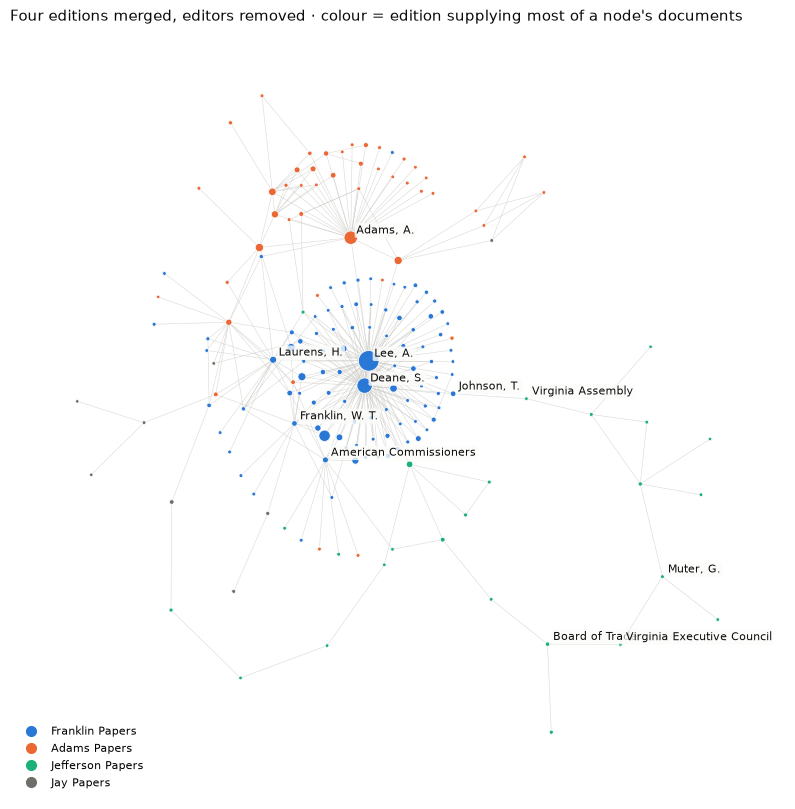

In [20]:
EDITORS = ["Franklin, Benjamin", "Adams, John", "Jefferson, Thomas", "Jay, John"]
H = nl.without(G, EDITORS)
MH = nl.metric_table(H)
MH["community"] = pd.Series(nl.communities(H, seed=42))
MH["main_edition"] = M["main_edition"]
print(nl.summary(H))
print("NMI without the editors =", round(nmi(MH.community, MH.main_edition), 3))
fig, ax = plt.subplots(figsize=(10, 10))
nl.draw(H, color_by=MH.main_edition.to_dict(), min_letters=3, ax=ax,
        labels=list(MH.sort_values("betweenness", ascending=False).index[:12]),
        title="Four editions merged, editors removed · colour = edition supplying most of a node's documents")
nl.legend_editions(ax)

In [21]:
nl.top(MH, "betweenness", 15, ["letters_total", "correspondents", "betweenness", "type", "main_edition"])

,letters_total,correspondents,betweenness,type,main_edition
"Lee, Arthur",1156,222,0.603186,person,Franklin
"Adams, Abigail",393,63,0.179615,person,Adams
"Franklin, William Temple",58,44,0.134962,person,Franklin
"Laurens, Henry",75,25,0.090414,person,Franklin
"Penet, D’Acosta frères & Cie.",2,2,0.082860,firm,Franklin
Board of Trade,13,6,0.082789,group,Jefferson
"Muter, George",17,14,0.068977,person,Jefferson
Virginia Executive Council,5,3,0.066941,group,Jefferson
American Commissioners,53,31,0.062805,group,Franklin
"Deane, Silas",522,94,0.061534,person,Franklin


**Question 7.** (a) What does the NMI tell you about reading these communities as historical groups? (b) Choose two nodes with high betweenness in the table above. Using their documents on Founders Online, say whether each was a *historical* intermediary or an *archival* one (someone whose papers happen to be filed with an edition's subject).

In [22]:
who = "Lee, Arthur"   # try: another name from the table
E[(E.source == who) | (E.target == who)].groupby(["edition"]).size().rename("documents").to_frame()

,documents
edition,
Adams,82
Franklin,1277
Jay,2
Jefferson,7


> **Your answer (Q7):**
>
> _Write here._

## Stage 8 · *(optional)* The network over time

Diplomatic tasks changed: the commission to France (1777–1779), missions to Madrid and The Hague (1779–1782), the peace negotiations (1782–1783). Yearly networks show who held each year's network together once the editors are removed.

In [23]:
yr = nl.yearly(E, exclude=EDITORS, top_n=4)
yr.pivot_table(index="year", columns=yr.groupby("year").cumcount() + 1, values="name", aggfunc="first")

,1,2,3,4
year,,,,
1777,"Lee, Arthur","Deane, Silas","Washington, George","Warren, James"
1778,"Lee, Arthur","Adams, Abigail","Lovell, James","Deane, Silas"
1779,"Lee, Arthur","Franklin, William Temple","Adams, Abigail","Lovell, James"
1780,"Adams, Abigail","Muter, George",Virginia Executive Council,Board of Trade
1781,"Davies, William","Muter, George","Adams, Abigail","Thaxter, John"
1782,"Franklin, William Temple","Livingston, Robert R.","Laurens, Henry","Adams, Abigail"
1783,American Peace Commissioners,"Thaxter, John","Franklin, William Temple","Adams, Abigail"
1784,American Commissioners,"Adams, Abigail","Hartley, David","Adams, John Quincy"


**Question 8.** Pick one year and connect the top names to what you know of that year's diplomacy. Which name is there for archival reasons?

> **Your answer (Q8):**
>
> _Write here._

## Stage 9 · *(optional)* How fragile are the rankings?

Archives lose documents. Simulate losing 20% of documents at random, 20 times, and compare the top 20 correspondents (editors excluded) with the full-data top 20. **Overlap** is the share of the top 20 that stays in the top 20.

In [24]:
res = []
for measure in ["letters_total", "betweenness"]:
    r = nl.rank_stability(E, measure, keep_share=0.8, reps=20, top=20, exclude=EDITORS)   # try: keep_share=0.6
    res.append(r.assign(measure=measure))
res = pd.concat(res)
res.groupby("measure")[["overlap", "spearman"]].agg(["mean", "min"]).round(2)

overlap       spearman      
                 mean   min     mean   min
measure                                   
betweenness      0.80  0.65     0.68  0.30
letters_total    0.99  0.95     0.98  0.96

Which measure is more robust to loss, and why would that be? What does this imply for claims about 'brokers' based on betweenness?

> **Your answer (Q9):**
>
> _Write here._

## Stage 10 · Memo (300 words)

Answer the research question for a reader who has not seen this notebook. Your memo must:

1. state **one** substantive claim about who connected American diplomacy in Europe, 1777–1784;
2. name the **two** data decisions (from Stages 1–6) that most affect that claim, and what changes if they are made differently;
3. cite **at least two documents** by permalink as evidence that the network result corresponds to a historical relationship;
4. state one thing this network **cannot** show.

> **Your answer (memo):**
>
> _Write here._

---
**Data:** Founders Online metadata (National Archives and University of Virginia Press), filtered to four editions, 1777–1784. See `data/README.md` for provenance and every transformation. **Code:** `netlab.py` (all functions used above, with docstrings).